In [ ]:
# Luis Jose Gonzalez Montilla 2024-0509

!pip install statsmodels scipy

import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy import stats

# Cargar datos
file_path = "hurricane_erin_case_study.xlsx"
data = pd.read_excel(file_path, sheet_name="data")

# Regresión múltiple
X = data[["max_wind_kts", "rainfall_mm_per_hr", "distance_to_SantoDomingo_km"]]
y = data["power_outages"]

model = LinearRegression()
model.fit(X, y)

print("Intercepto (β0):", model.intercept_)
print("Coeficientes (β1, β2, β3):", model.coef_)
print("R²:", model.score(X, y))

# Contraste de hipótesis
mu0 = 30
x = data["max_wind_kts"]

t_stat, p_value = stats.ttest_1samp(x, mu0)

# Unilateral
if t_stat > 0:
    p_value = p_value / 2
else:
    p_value = 1 - p_value / 2

print("\nMedia del viento:", x.mean())
print("t estadístico:", t_stat)
print("p-valor unilateral:", p_value)

if p_value < 0.05:
    print("Rechazamos H0: la media del viento > 30 kt")
else:
    print("No se rechaza H0: no hay evidencia de que supere 30 kt")


Intercepto (β0): -46.320897942476726
Coeficientes (β1, β2, β3): [0.66040638 0.6694895  0.02434028]
R²: 0.7828172044395438

Media del viento: 60.37416666666666
t estadístico: 11.664389334377294
p-valor unilateral: 9.899769769376659e-22
Rechazamos H0: la media del viento > 30 kt


                            OLS Regression Results                            
Dep. Variable:          power_outages   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     139.4
Date:                Wed, 20 Aug 2025   Prob (F-statistic):           2.63e-38
Time:                        21:55:01   Log-Likelihood:                -408.63
No. Observations:                 120   AIC:                             825.3
Df Residuals:                     116   BIC:                             836.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

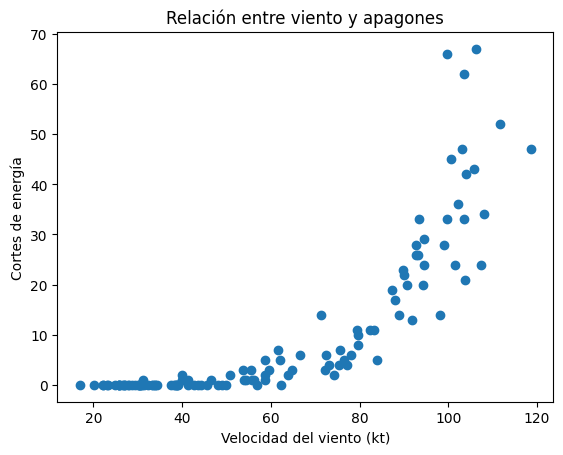

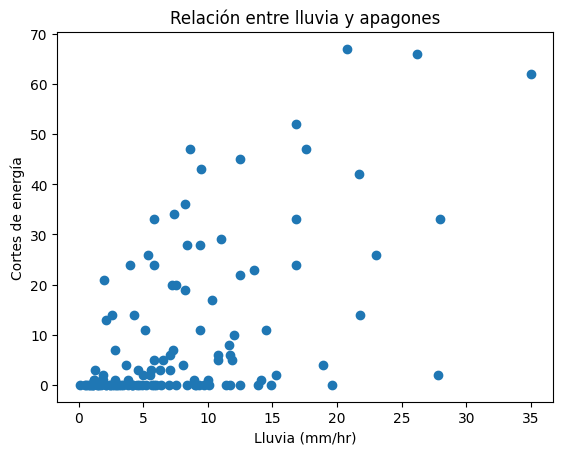

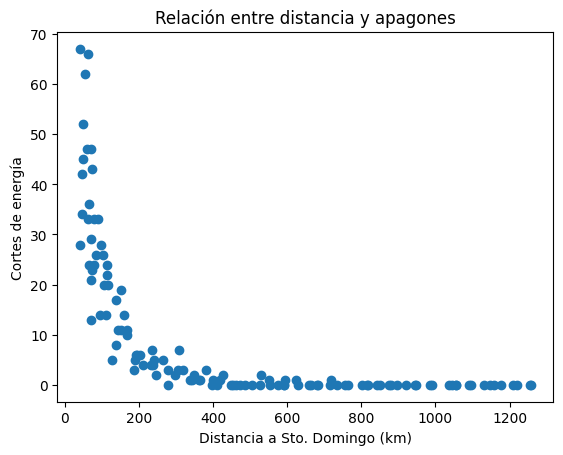

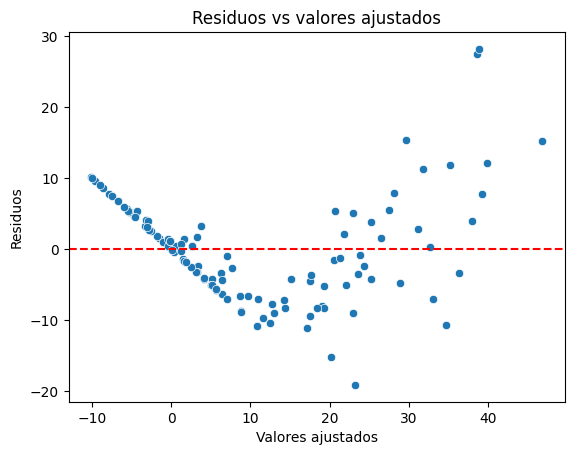

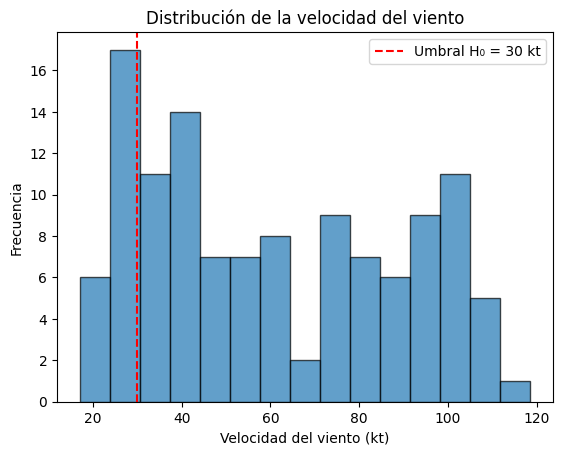

In [ ]:
# Luis Jose Gonzalez Montilla 2024-0509
# Análisis

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
file_path = "hurricane_erin_case_study.xlsx"
df = pd.read_excel(file_path, sheet_name="data")

# Modelo de regresión múltiple

X = df[["max_wind_kts", "rainfall_mm_per_hr", "distance_to_SantoDomingo_km"]]
y = df["power_outages"]
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Gráficos

# Gráfico 1: viento vs apagones
plt.scatter(df["max_wind_kts"], df["power_outages"])
plt.xlabel("Velocidad del viento (kt)")
plt.ylabel("Cortes de energía")
plt.title("Relación entre viento y apagones")
plt.show()

# Gráfico 2: lluvia vs apagones
plt.scatter(df["rainfall_mm_per_hr"], df["power_outages"])
plt.xlabel("Lluvia (mm/hr)")
plt.ylabel("Cortes de energía")
plt.title("Relación entre lluvia y apagones")
plt.show()

# Gráfico 3: distancia vs apagones
plt.scatter(df["distance_to_SantoDomingo_km"], df["power_outages"])
plt.xlabel("Distancia a Sto. Domingo (km)")
plt.ylabel("Cortes de energía")
plt.title("Relación entre distancia y apagones")
plt.show()

# Gráfico 4: residuos vs valores ajustados
residuos = modelo.resid
ajustados = modelo.fittedvalues

sns.scatterplot(x=ajustados, y=residuos)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()

# Histograma de la velocidad del viento con línea en 30 kt (hipótesis nula)
plt.hist(df["max_wind_kts"], bins=15, edgecolor="black", alpha=0.7)
plt.axvline(30, color="red", linestyle="--", label="Umbral H₀ = 30 kt")
plt.xlabel("Velocidad del viento (kt)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la velocidad del viento")
plt.legend()
plt.show()


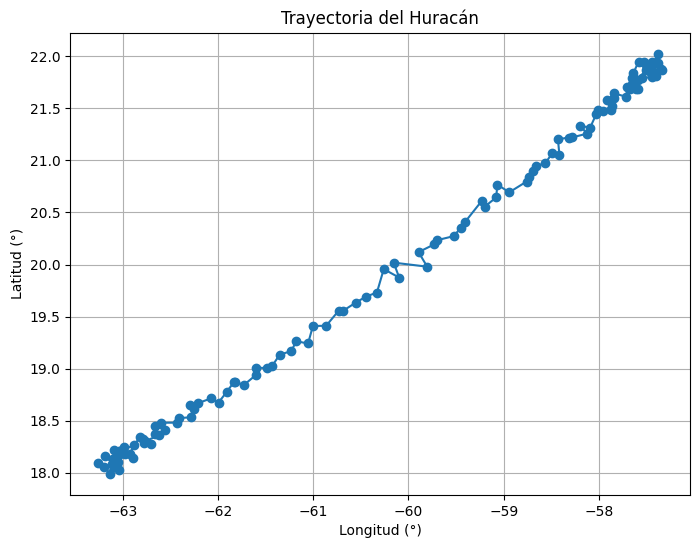

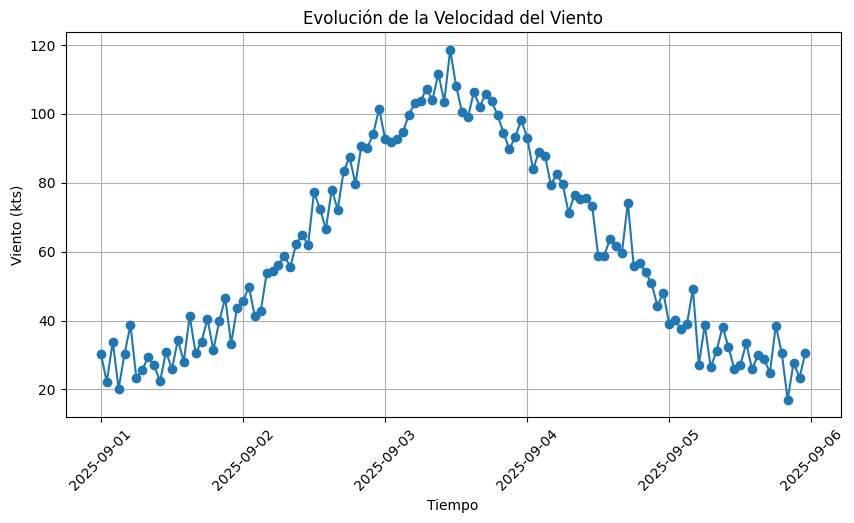

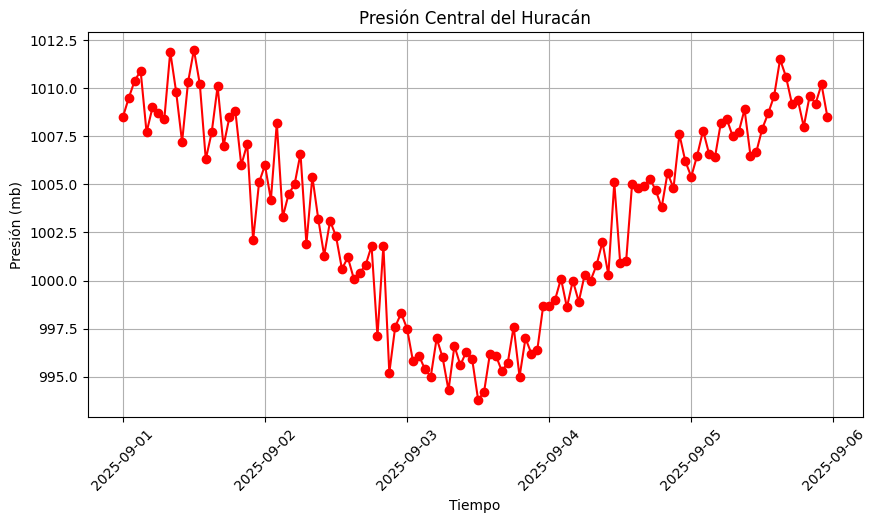

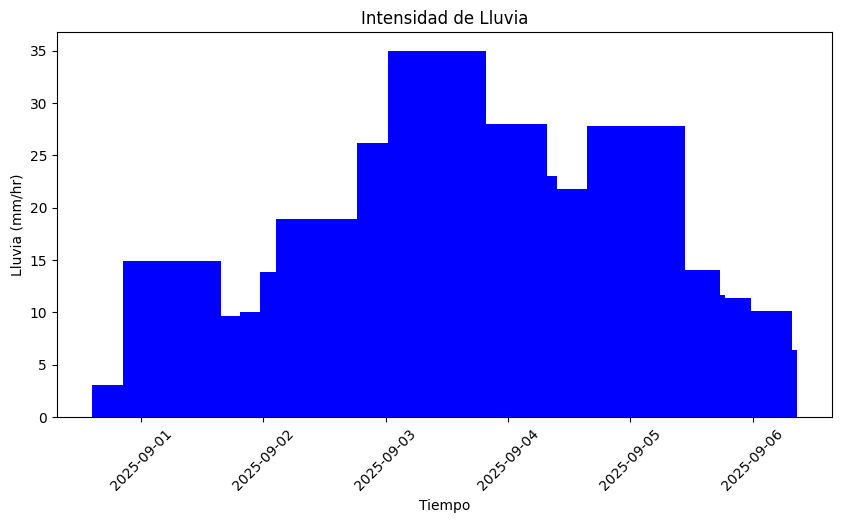

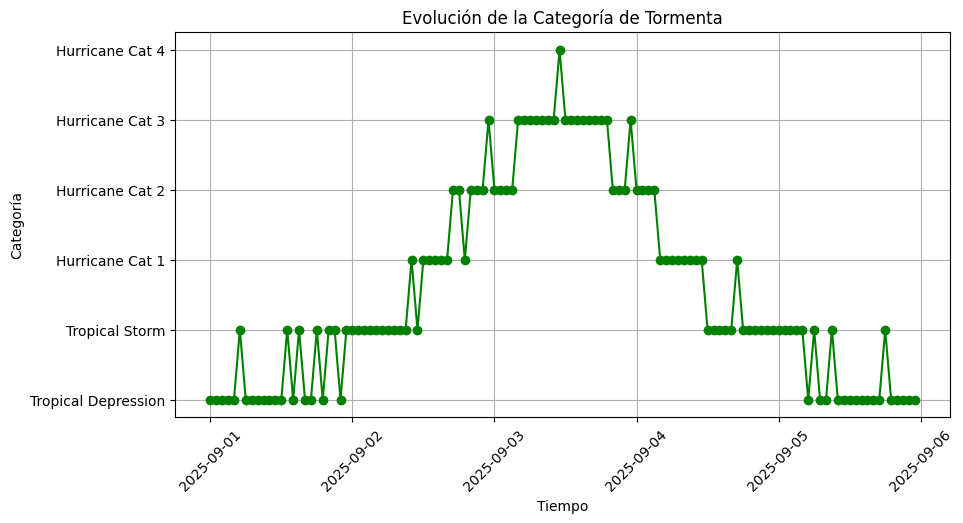

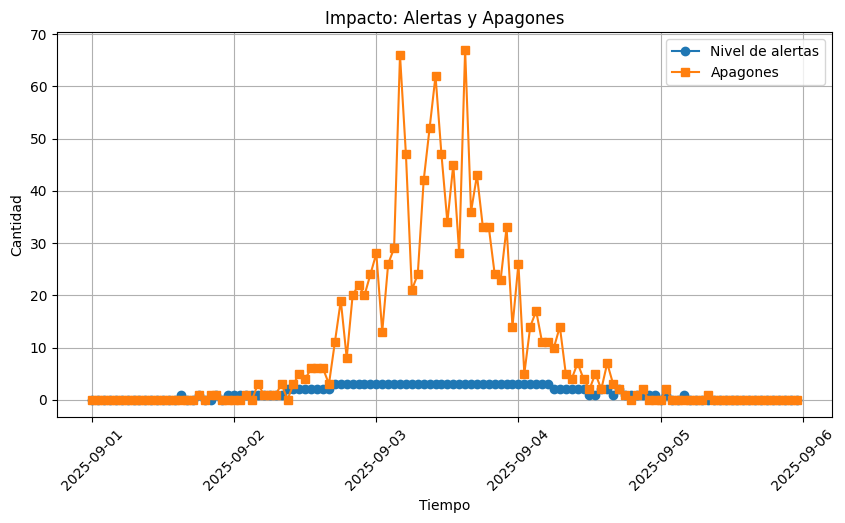

In [ ]:
# Luis Jose Gonzalez Montilla 2024-0509

import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo
file_path = "hurricane_erin_case_study.xlsx"
data = pd.read_excel(file_path, sheet_name="data")

# 1. Trayectoria del huracán
plt.figure(figsize=(8,6))
plt.plot(data["lon_deg"], data["lat_deg"], marker="o", linestyle="-")
plt.title("Trayectoria del Huracán")
plt.xlabel("Longitud (°)")
plt.ylabel("Latitud (°)")
plt.grid()
plt.show()

# 2. Evolución del viento
plt.figure(figsize=(10,5))
plt.plot(data["timestamp_utc"], data["max_wind_kts"], marker="o")
plt.title("Evolución de la Velocidad del Viento")
plt.xlabel("Tiempo")
plt.ylabel("Viento (kts)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 3. Evolución de la presión
plt.figure(figsize=(10,5))
plt.plot(data["timestamp_utc"], data["central_pressure_mb"], color="red", marker="o")
plt.title("Presión Central del Huracán")
plt.xlabel("Tiempo")
plt.ylabel("Presión (mb)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4. Lluvia acumulada
plt.figure(figsize=(10,5))
plt.bar(data["timestamp_utc"], data["rainfall_mm_per_hr"], color="blue")
plt.title("Intensidad de Lluvia")
plt.xlabel("Tiempo")
plt.ylabel("Lluvia (mm/hr)")
plt.xticks(rotation=45)
plt.show()

# 5. Categoría de tormenta
plt.figure(figsize=(10,5))
plt.plot(data["timestamp_utc"], data["storm_category"], marker="o", color="green")
plt.title("Evolución de la Categoría de Tormenta")
plt.xlabel("Tiempo")
plt.ylabel("Categoría")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6. Impacto: alertas y apagones
plt.figure(figsize=(10,5))
plt.plot(data["timestamp_utc"], data["alerts_level"], label="Nivel de alertas", marker="o")
plt.plot(data["timestamp_utc"], data["power_outages"], label="Apagones", marker="s")
plt.title("Impacto: Alertas y Apagones")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()
